# Notebook 21 — Invertible Neural Network (A2 CNN + B3 RealNVP)

**Goal**: Train a **RealNVP-based Invertible Neural Network (INN)** that maps between
design parameters (20-D) and a latent Gaussian conditioned on the target spectrum.

| Aspect | Detail |
|--------|--------|
| **Forward surrogate** | A2 CNN (frozen, from Notebook 18) |
| **Inverse method** | RealNVP with spectrum-conditioned affine coupling |
| **Flow layers** | 8 affine coupling blocks |
| **Loss** | Negative log-likelihood + λ·Spectral MSE |
| **Key advantage** | Exact density; invertible → can sample + evaluate probability |

In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================
import sys, os, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath('../src'))
from Theoretical_model import calculate_acoustic_properties
from physics_guided_CD_FiLM import PARAM_RANGES, validate_and_clip_parameters

assert torch.cuda.is_available(), 'CUDA required'
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f'Device: {torch.cuda.get_device_name()}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Paths
DATA_PATH      = '../data/Data/lhs_data_full_spectrum.npz'
MODEL_DIR      = '../models'
SURROGATE_PATH = os.path.join(MODEL_DIR, 'forward_surrogate_cnn.pth')
SCALER_PATH    = os.path.join(MODEL_DIR, 'forward_surrogate_cnn_scaler.pkl')
INN_PATH       = os.path.join(MODEL_DIR, 'inverse_inn_a2.pth')
INN_SCALER     = os.path.join(MODEL_DIR, 'inverse_inn_a2_scaler.pkl')

# Hyper-parameters
BATCH_SIZE     = 256
EPOCHS         = 50
LR_INIT        = 5e-4
LR_MIN         = 1e-6
HIDDEN_DIM     = 256       # coupling net hidden
SPEC_EMBED_DIM = 512
NUM_COUPLING   = 8
LAMBDA_SPEC    = 0.5       # spectral loss weight
SPEC_RAMP      = 10        # epochs to ramp λ
NUM_PARAMS     = 20
NUM_FREQ       = 1000
NUM_CANDIDATES = 20

PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']

print('\n✓ Imports & config ready')

Device: NVIDIA GeForce RTX 2060 SUPER

✓ Imports & config ready


In [2]:
# ============================================================
# Cell 2 — Load Data & Split
# ============================================================
print('Loading NPZ …')
t0 = time.time()
raw = np.load(DATA_PATH)
params_all  = raw['params'].astype(np.float32)
spectra_all = raw['spectra'].astype(np.float32)
frequencies = raw['frequencies']
print(f'  Loaded in {time.time()-t0:.1f}s')

X_train, X_temp, Y_train, Y_temp = train_test_split(
    params_all, spectra_all, test_size=0.2, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=SEED)

print(f'  Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

scaler_x = MinMaxScaler()
X_train_n = scaler_x.fit_transform(X_train).astype(np.float32)
X_val_n   = scaler_x.transform(X_val).astype(np.float32)
X_test_n  = scaler_x.transform(X_test).astype(np.float32)

def make_loader(spec, params_n, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(spec, dtype=torch.float32),
                       torch.tensor(params_n, dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=True)

train_loader = make_loader(Y_train, X_train_n, BATCH_SIZE)
val_loader   = make_loader(Y_val,   X_val_n,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(Y_test,  X_test_n,  BATCH_SIZE, shuffle=False)
print('✓ Data ready')

Loading NPZ …
  Loaded in 53.9s
  Train: 800,000  Val: 100,000  Test: 100,000
✓ Data ready


In [3]:
# ============================================================
# Cell 3 — Load Forward Surrogate (frozen)
# ============================================================
class ForwardSurrogateCNN(nn.Module):
    def __init__(self, in_dim=20, out_dim=1000):
        super().__init__()
        self.in_dim = in_dim; self.out_dim = out_dim
        self.stem = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(256, 128*32), nn.BatchNorm1d(128*32), nn.LeakyReLU(0.01, inplace=True))
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 4, 2, 1), nn.BatchNorm1d(64), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.BatchNorm1d(32), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.BatchNorm1d(16), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(16, 8, 4, 2, 1), nn.BatchNorm1d(8), nn.LeakyReLU(0.01, inplace=True))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(8*512, 1024),
            nn.LeakyReLU(0.01, inplace=True), nn.Linear(1024, out_dim), nn.Sigmoid())
    def forward(self, x):
        h = self.stem(x); h = h.view(-1, 128, 32); h = self.decoder(h); return self.head(h)

ckpt_surr = torch.load(SURROGATE_PATH, map_location=device, weights_only=False)
arch = ckpt_surr['architecture']
surrogate = ForwardSurrogateCNN(**arch).to(device)
surrogate.load_state_dict(ckpt_surr['model_state_dict'])
surrogate.eval()
for p in surrogate.parameters(): p.requires_grad = False
print(f'✓ Surrogate loaded (MSE={ckpt_surr["test_metrics"]["spectral_mse"]:.2e})')

✓ Surrogate loaded (MSE=3.90e-05)


In [4]:
# ============================================================
# Cell 4 — RealNVP Model Definition
# ============================================================

class SpectrumEncoder(nn.Module):
    """1D-CNN: 1000-point spectrum → embedding."""
    def __init__(self, embed_dim=512):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32,  kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.LeakyReLU(0.01, inplace=True),
            nn.Conv1d(32, 64,  kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.LeakyReLU(0.01, inplace=True),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.LeakyReLU(0.01, inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(nn.Linear(128, embed_dim), nn.LeakyReLU(0.01, inplace=True))

    def forward(self, spectrum):
        x = spectrum.unsqueeze(1)
        return self.fc(self.conv(x).squeeze(-1))


class AffineCouplingLayer(nn.Module):
    """Conditional affine coupling: split x into (x_a, x_b) and transform x_b."""
    def __init__(self, dim, split_idx, cond_dim, hidden_dim=256):
        super().__init__()
        self.split_idx = split_idx
        in_a = split_idx
        in_b = dim - split_idx
        # s and t networks
        self.net_s = nn.Sequential(
            nn.Linear(in_a + cond_dim, hidden_dim),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(hidden_dim, in_b),
            nn.Tanh(),                               # bound log_s to (-1, 1)
        )
        self.net_t = nn.Sequential(
            nn.Linear(in_a + cond_dim, hidden_dim),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(hidden_dim, in_b),
        )

    def forward(self, x, cond):
        """Forward: params → latent (x → z). Returns z, log_det."""
        x_a, x_b = x[:, :self.split_idx], x[:, self.split_idx:]
        inp = torch.cat([x_a, cond], dim=-1)
        log_s = self.net_s(inp)
        t     = self.net_t(inp)
        z_b   = x_b * torch.exp(log_s) + t
        log_det = log_s.sum(dim=-1)
        return torch.cat([x_a, z_b], dim=-1), log_det

    def inverse(self, z, cond):
        """Inverse: latent → params (z → x)."""
        z_a, z_b = z[:, :self.split_idx], z[:, self.split_idx:]
        inp = torch.cat([z_a, cond], dim=-1)
        log_s = self.net_s(inp)
        t     = self.net_t(inp)
        x_b   = (z_b - t) * torch.exp(-log_s)
        return torch.cat([z_a, x_b], dim=-1)


class ConditionalRealNVP(nn.Module):
    """Spectrum-conditioned RealNVP."""
    def __init__(self, dim=20, num_coupling=8, cond_dim=512, hidden_dim=256):
        super().__init__()
        self.dim = dim
        self.spec_enc = SpectrumEncoder(embed_dim=cond_dim)
        self.layers = nn.ModuleList()

        for i in range(num_coupling):
            # Alternate split: first half / second half
            if i % 2 == 0:
                split_idx = dim // 2
            else:
                split_idx = dim - dim // 2
            self.layers.append(
                AffineCouplingLayer(dim, split_idx, cond_dim, hidden_dim))

        # Learnable permutation indices (fixed random permutation per layer)
        self.perms = []
        self.inv_perms = []
        for i in range(num_coupling - 1):  # no permutation after last layer
            perm = torch.randperm(dim)
            inv_perm = torch.argsort(perm)
            self.register_buffer(f'perm_{i}', perm)
            self.register_buffer(f'inv_perm_{i}', inv_perm)
            self.perms.append(perm)
            self.inv_perms.append(inv_perm)

    def forward(self, params, spectrum):
        """Forward: params → z.  Returns z, total_log_det."""
        cond = self.spec_enc(spectrum)
        z = params
        total_log_det = 0.0
        for i, layer in enumerate(self.layers):
            z, log_det = layer(z, cond)
            total_log_det = total_log_det + log_det
            if i < len(self.layers) - 1:
                z = z[:, getattr(self, f'perm_{i}')]
        return z, total_log_det

    def inverse(self, z, spectrum):
        """Inverse: z → params."""
        cond = self.spec_enc(spectrum)
        x = z
        for i in reversed(range(len(self.layers))):
            if i < len(self.layers) - 1:
                x = x[:, getattr(self, f'inv_perm_{i}')]
            x = self.layers[i].inverse(x, cond)
        return x

    @torch.no_grad()
    def sample(self, spectrum, num_samples=1):
        """Sample params from prior z~N(0,I)."""
        cond = self.spec_enc(spectrum)
        if num_samples > 1 and cond.size(0) == 1:
            cond = cond.expand(num_samples, -1)
        z = torch.randn(cond.size(0), self.dim, device=cond.device) * 0.8  # temp < 1 → sharper
        # Inverse through all layers
        x = z
        for i in reversed(range(len(self.layers))):
            if i < len(self.layers) - 1:
                x = x[:, getattr(self, f'inv_perm_{i}')]
            x = self.layers[i].inverse(x, cond)
        return x.clamp(0, 1)  # params are normalized to [0,1]


inn = ConditionalRealNVP(
    dim=NUM_PARAMS, num_coupling=NUM_COUPLING, cond_dim=SPEC_EMBED_DIM,
    hidden_dim=HIDDEN_DIM
).to(device)

total_p = sum(p.numel() for p in inn.parameters())
print(f'✓ ConditionalRealNVP — {total_p:,} params ({NUM_COUPLING} coupling layers)')

✓ ConditionalRealNVP — 3,337,760 params (8 coupling layers)


In [5]:
# ============================================================
# Cell 5 — Loss, Optimiser, Scheduler
# ============================================================
def build_freq_weights(num_freq=1000, low_cutoff=400, low_weight=2.0, device='cpu'):
    w = torch.ones(num_freq, device=device)
    w[:low_cutoff] = low_weight
    return w / w.mean()

freq_w = build_freq_weights(device=device)

log2pi = np.log(2 * np.pi)

def nll_loss(z, log_det):
    """Negative log-likelihood under standard Gaussian prior."""
    log_pz = -0.5 * (z.pow(2) + log2pi).sum(dim=-1)  # log p(z)
    log_px = log_pz + log_det                          # log p(x) = log p(z) + log|det|
    return -log_px.mean()


def inn_loss(z, log_det, pred_params, target_spec, surrogate_fn, lam_spec=0.5):
    L_nll = nll_loss(z, log_det)
    # Spectral consistency through surrogate
    recon_spec = surrogate_fn(pred_params.clamp(0, 1))
    L_spec = ((recon_spec - target_spec)**2 * freq_w).mean()
    return L_nll + lam_spec * L_spec, L_nll.item(), L_spec.item()


optimizer = optim.Adam(inn.parameters(), lr=LR_INIT, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)
print('✓ Loss & optimiser configured')

✓ Loss & optimiser configured


In [6]:
# ============================================================
# Cell 6 — Training Loop
# ============================================================
train_losses, val_losses = [], []
train_nll, val_nll       = [], []
best_val  = float('inf')
best_state = None

print(f'Training {EPOCHS} epochs …\n')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    lam = min(LAMBDA_SPEC, LAMBDA_SPEC * epoch / SPEC_RAMP)

    # ----- Train -----
    inn.train()
    ep_loss, ep_nll = 0.0, 0.0
    for spec_b, params_b in train_loader:
        spec_b, params_b = spec_b.to(device), params_b.to(device)
        z, log_det = inn(params_b, spec_b)
        loss, l_nll, l_spec = inn_loss(z, log_det, params_b, spec_b, surrogate, lam)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(inn.parameters(), max_norm=5.0)
        optimizer.step()

        bs = spec_b.size(0)
        ep_loss += loss.item() * bs
        ep_nll  += l_nll * bs

    train_losses.append(ep_loss / len(train_loader.dataset))
    train_nll.append(ep_nll / len(train_loader.dataset))

    # ----- Validate -----
    inn.eval()
    v_loss, v_nll = 0.0, 0.0
    with torch.no_grad():
        for spec_b, params_b in val_loader:
            spec_b, params_b = spec_b.to(device), params_b.to(device)
            z, log_det = inn(params_b, spec_b)
            loss, l_nll, _ = inn_loss(z, log_det, params_b, spec_b, surrogate, lam)
            v_loss += loss.item() * spec_b.size(0)
            v_nll  += l_nll * spec_b.size(0)

    val_losses.append(v_loss / len(val_loader.dataset))
    val_nll.append(v_nll / len(val_loader.dataset))
    scheduler.step()

    if val_losses[-1] < best_val:
        best_val   = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in inn.state_dict().items()}
        tag = ' ★'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch:3d}/{EPOCHS}  train {train_losses[-1]:.4f}  '
              f'val {val_losses[-1]:.4f}  NLL {val_nll[-1]:.4f}  λ {lam:.3f}  lr {lr:.2e}{tag}')

elapsed = time.time() - t_start
print(f'\n✓ Training complete in {elapsed/60:.1f} min — best val = {best_val:.4f}')
inn.load_state_dict(best_state)
inn.to(device)
print('  Best checkpoint restored')

Training 50 epochs …

  Epoch   1/50  train 0.1590  val 11.5034  NLL 11.5034  λ 0.050  lr 5.00e-04 ★
  Epoch   5/50  train -3.8202  val -2.6491  NLL -2.6491  λ 0.250  lr 4.88e-04 ★
  Epoch  10/50  train -5.2459  val 73.8995  NLL 73.8995  λ 0.500  lr 4.52e-04
  Epoch  15/50  train -5.7832  val 381.1614  NLL 381.1614  λ 0.500  lr 3.97e-04
  Epoch  20/50  train -6.6480  val -2.2860  NLL -2.2860  λ 0.500  lr 3.28e-04
  Epoch  25/50  train -6.8999  val 14.6616  NLL 14.6616  λ 0.500  lr 2.51e-04
  Epoch  30/50  train -7.7867  val 51.3210  NLL 51.3210  λ 0.500  lr 1.73e-04
  Epoch  35/50  train -8.5677  val 13.8495  NLL 13.8495  λ 0.500  lr 1.04e-04
  Epoch  40/50  train -9.1773  val 24.1553  NLL 24.1553  λ 0.500  lr 4.87e-05
  Epoch  45/50  train -9.5407  val -9.9587  NLL -9.9587  λ 0.500  lr 1.32e-05 ★
  Epoch  50/50  train -9.7172  val -10.4301  NLL -10.4301  λ 0.500  lr 1.00e-06 ★

✓ Training complete in 103.1 min — best val = -10.4301
  Best checkpoint restored


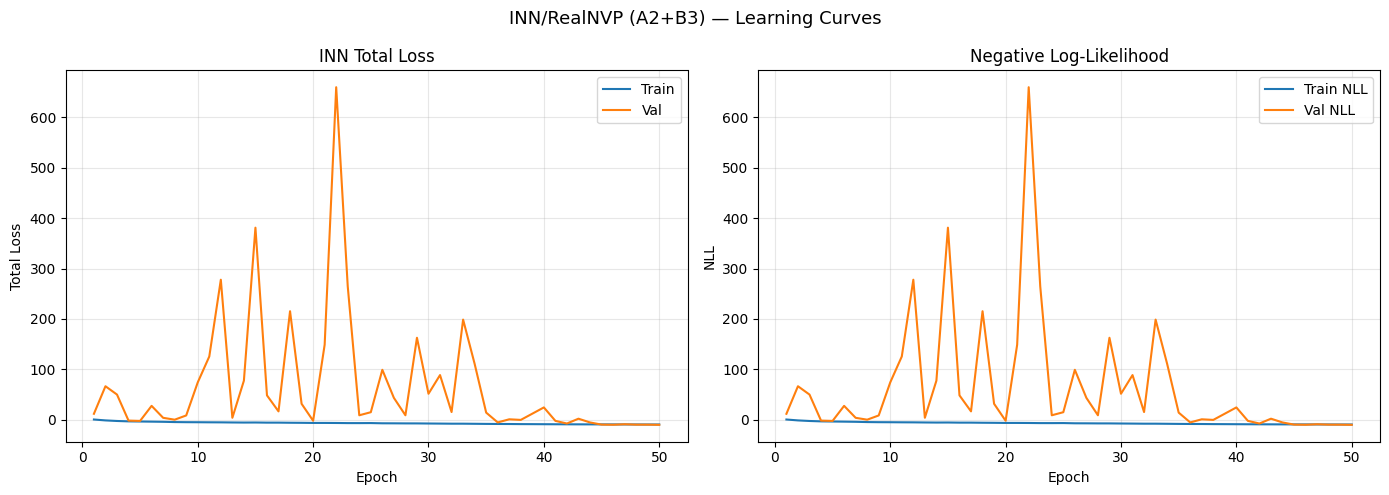

In [7]:
# ============================================================
# Cell 7 — Learning Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, label='Train')
ax1.plot(range(1, EPOCHS+1), val_losses,   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Total Loss')
ax1.set_title('INN Total Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), train_nll, label='Train NLL')
ax2.plot(range(1, EPOCHS+1), val_nll,   label='Val NLL')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('NLL')
ax2.set_title('Negative Log-Likelihood'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('INN/RealNVP (A2+B3) — Learning Curves', fontsize=13)
plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# Cell 8 — Test Metrics (single sample)
# ============================================================
inn.eval()
all_spec_mse = []

with torch.no_grad():
    for spec_b, _ in test_loader:
        spec_b = spec_b.to(device)
        pred_params = inn.sample(spec_b, num_samples=1)
        recon_spec  = surrogate(pred_params)
        mse = ((recon_spec - spec_b)**2).mean(dim=1)
        all_spec_mse.append(mse.cpu().numpy())

spec_mse_arr = np.concatenate(all_spec_mse)
print('═══════════════════════════════════════════')
print('  TEST METRICS — INN/RealNVP (A2+B3), single sample')
print('═══════════════════════════════════════════')
print(f'  Mean spectral MSE   : {spec_mse_arr.mean():.6e}')
print(f'  Median spectral MSE : {np.median(spec_mse_arr):.6e}')
for p in [90, 95, 99]:
    print(f'  {p}th pctile MSE    : {np.percentile(spec_mse_arr, p):.6e}')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
  TEST METRICS — INN/RealNVP (A2+B3), single sample
═══════════════════════════════════════════
  Mean spectral MSE   : 1.061553e-04
  Median spectral MSE : 1.510883e-05
  90th pctile MSE    : 1.178470e-04
  95th pctile MSE    : 2.939543e-04
  99th pctile MSE    : 1.692281e-03
═══════════════════════════════════════════


In [9]:
# ============================================================
# Cell 9 — Best-of-N Test (20 candidates per target)
# ============================================================
np.random.seed(123)
bon_idx = np.random.choice(len(X_test), 200, replace=False)

bon_mse = []
inn.eval()
with torch.no_grad():
    for idx in bon_idx:
        spec_t = torch.tensor(Y_test[idx], dtype=torch.float32, device=device).unsqueeze(0)
        cands  = inn.sample(spec_t, num_samples=NUM_CANDIDATES)
        specs  = surrogate(cands)
        mses   = ((specs - spec_t)**2).mean(dim=1)
        bon_mse.append(mses.min().item())

bon_mse = np.array(bon_mse)
print(f'Best-of-{NUM_CANDIDATES} test (200 targets):')
print(f'  Mean MSE : {bon_mse.mean():.6e}')
print(f'  Median   : {np.median(bon_mse):.6e}')
print(f'  95th pct : {np.percentile(bon_mse, 95):.6e}')

Best-of-20 test (200 targets):
  Mean MSE : 3.078579e-05
  Median   : 2.100498e-06
  95th pct : 6.313243e-05


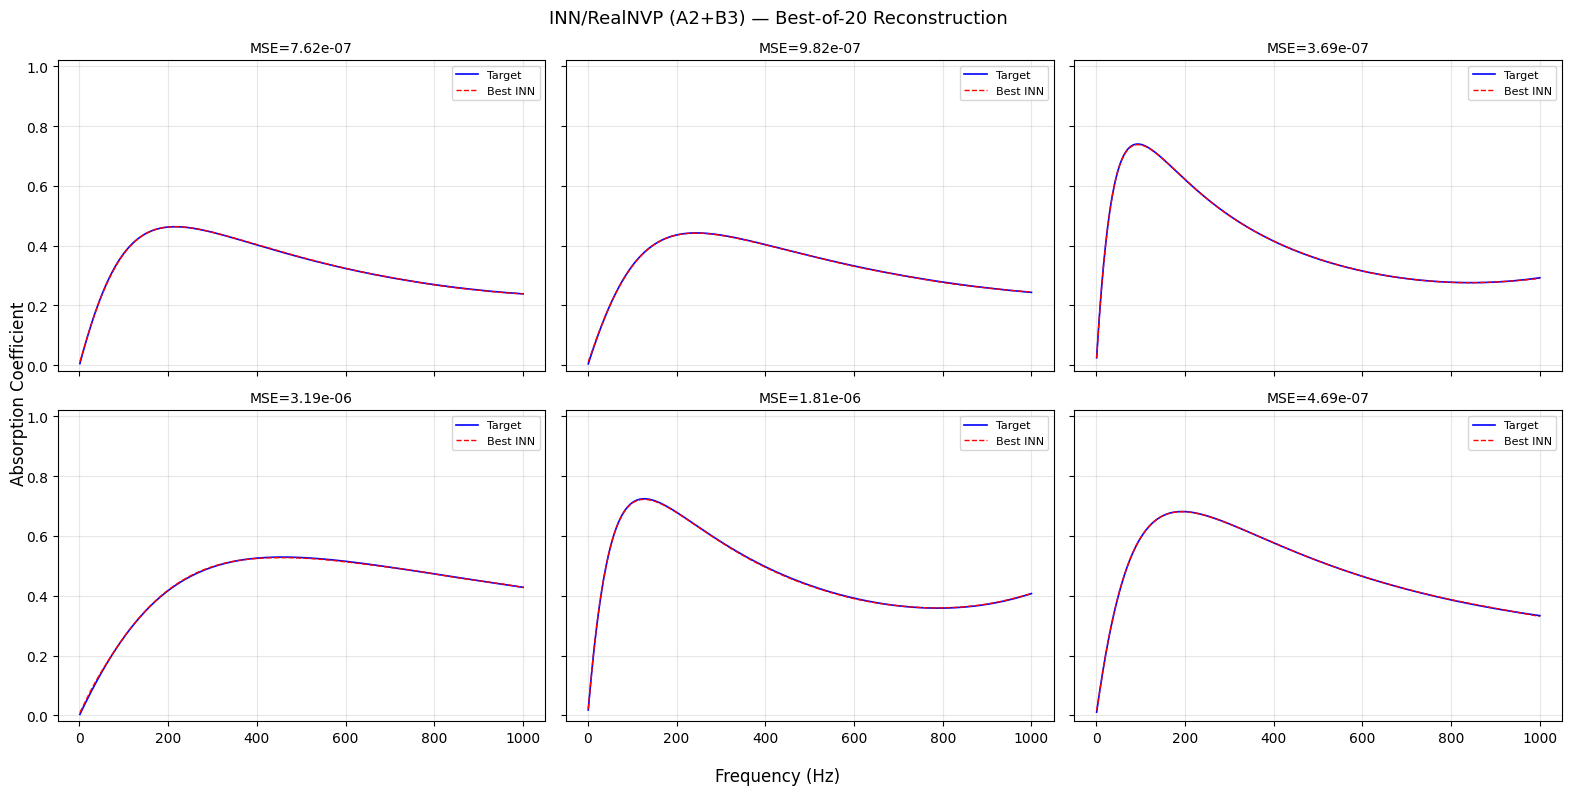

In [10]:
# ============================================================
# Cell 10 — Overlay: 6 Spectra
# ============================================================
np.random.seed(77)
show_idx = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
inn.eval()
for ax, idx in zip(axes.flat, show_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        cands = inn.sample(spec_t, num_samples=NUM_CANDIDATES)
        specs = surrogate(cands)
        mses  = ((specs - spec_t)**2).mean(dim=1)
        best  = specs[mses.argmin()].cpu().numpy()

    ax.plot(frequencies, target, 'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, best,   'r--', lw=1.0, label='Best INN')
    ax.set_title(f'MSE={mses.min().item():.2e}', fontsize=10)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('INN/RealNVP (A2+B3) — Best-of-20 Reconstruction', fontsize=13)
plt.tight_layout(); plt.show()

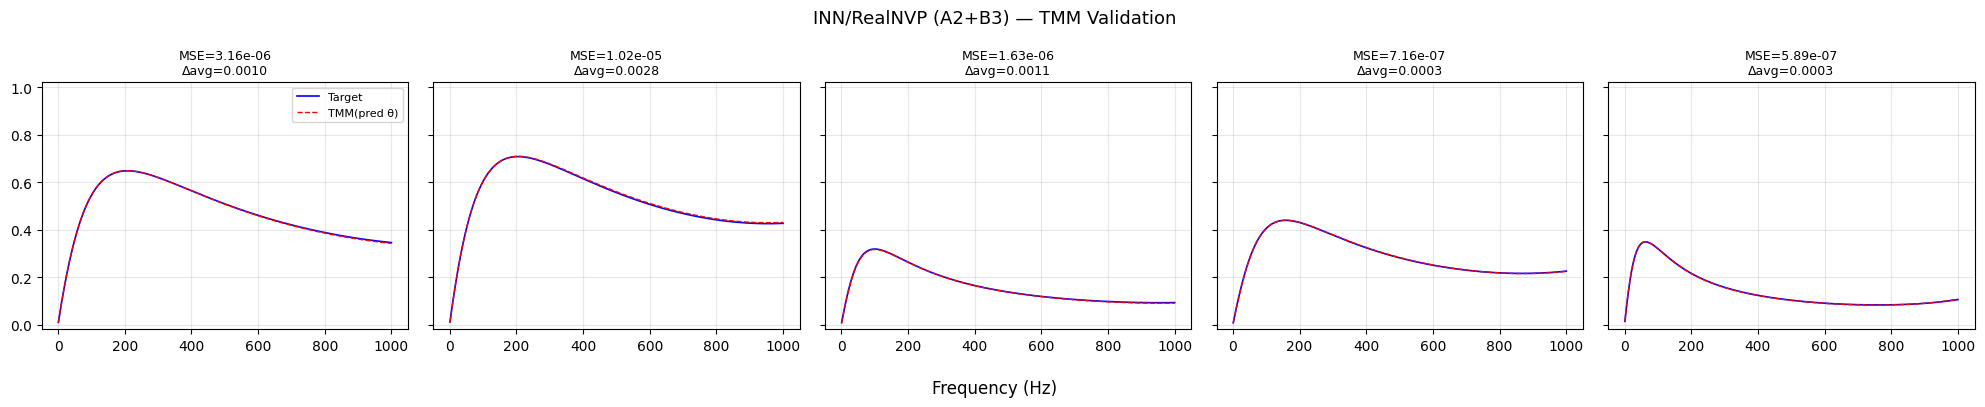


  TMM Validation:
    Sample  86155  MSE=3.1567e-06  Δavg=0.0010
    Sample  29633  MSE=1.0189e-05  Δavg=0.0028
    Sample  67710  MSE=1.6278e-06  Δavg=0.0011
    Sample  62348  MSE=7.1647e-07  Δavg=0.0003
    Sample  98787  MSE=5.8916e-07  Δavg=0.0003
  Mean TMM MSE: 3.2559e-06


In [11]:
# ============================================================
# Cell 11 — TMM Validation (5 samples)
# ============================================================
NUM_TMM = 5
np.random.seed(99)
tmm_idx = np.random.choice(len(X_test), NUM_TMM, replace=False)

fig, axes = plt.subplots(1, NUM_TMM, figsize=(20, 4), sharex=True, sharey=True)
tmm_results = []

for ax, idx in zip(axes, tmm_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        cands = inn.sample(spec_t, num_samples=NUM_CANDIDATES)
        specs = surrogate(cands)
        mses  = ((specs - spec_t)**2).mean(dim=1)
        best_n = cands[mses.argmin()].cpu().numpy()

    best_raw = scaler_x.inverse_transform(best_n.reshape(1, -1)).flatten()
    best_raw = validate_and_clip_parameters(best_raw.reshape(1, -1)).flatten()

    param_dict = {
        'rho': float(best_raw[16]), 'eta': float(best_raw[17]),
        'E': float(best_raw[18]), 'nu': float(best_raw[19]), 'W': 2000.0,
        'd': [float(best_raw[i]) for i in range(10)],
        'm': {2: float(best_raw[10]), 3: float(best_raw[11]),
              5: float(best_raw[12]), 6: float(best_raw[13]),
              8: float(best_raw[14]), 9: float(best_raw[15])}
    }
    _, alpha_tmm, _, _ = calculate_acoustic_properties(param_dict)

    mse_tmm = np.mean((alpha_tmm - target)**2)
    avg_err = abs(alpha_tmm.mean() - target.mean())
    tmm_results.append({'idx': idx, 'mse': mse_tmm, 'avg_err': avg_err})

    ax.plot(frequencies, target,    'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, alpha_tmm, 'r--', lw=1.0, label='TMM(pred θ)')
    ax.set_title(f'MSE={mse_tmm:.2e}\nΔavg={avg_err:.4f}', fontsize=9)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    if idx == tmm_idx[0]: ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.suptitle('INN/RealNVP (A2+B3) — TMM Validation', fontsize=13)
plt.tight_layout(); plt.show()

print('\n  TMM Validation:')
for r in tmm_results:
    print(f'    Sample {r["idx"]:6d}  MSE={r["mse"]:.4e}  Δavg={r["avg_err"]:.4f}')
print(f'  Mean TMM MSE: {np.mean([r["mse"] for r in tmm_results]):.4e}')

In [12]:
# ============================================================
# Cell 12 — Save Model
# ============================================================
torch.save({
    'model_state_dict': inn.state_dict(),
    'architecture': {
        'dim': NUM_PARAMS, 'num_coupling': NUM_COUPLING,
        'cond_dim': SPEC_EMBED_DIM, 'hidden_dim': HIDDEN_DIM,
    },
    'train_loss': train_losses, 'val_loss': val_losses,
    'best_val_loss': best_val,
    'surrogate_path': SURROGATE_PATH,
}, INN_PATH)

with open(INN_SCALER, 'wb') as f:
    pickle.dump(scaler_x, f)

print(f'✓ Model saved → {INN_PATH}  ({os.path.getsize(INN_PATH)/1e6:.1f} MB)')

✓ Model saved → ../models\inverse_inn_a2.pth  (13.4 MB)


---
## Summary

| Metric | Value |
|--------|-------|
| Architecture | RealNVP: 8 conditional affine coupling layers |
| Forward surrogate | A2 CNN (frozen) |
| Loss | NLL + λ·Spectral MSE (through frozen surrogate) |
| Inference | Single pass inverse (fast) + multi-sample via Gaussian prior |

**Key advantage:** Exact density estimation; trivially invertible.  
**Limitation:** Coupling layers can struggle with complex multi-modal distributions in 20-D.